In [ ]:
# 1 - Setup and dataset

from datasets import load_dataset
import os
import torch
from torch.utils.data import Subset

from IPPy.utilities.metrics import PSNR, SSIM, RE

from models.heuristic_hqs_pnp import DRUNetDenoiser, PnPHQSRegularizer
from models.network_unet import UNetRes
from nafnet_heightmap.network_naf_net import NAFNet
from models.heuristic_dgp import DGPImageReconstruction
from utilities.image_dataset import ImageDataset
from utilities.degradation import ImageDegradation, DegradationParameters
from utilities.plotter import plot 
from utilities.config import TEST_SIZE, TO_RECONSTRUCT_INDEXES
from models.heuristic_tv_regularizer import TotalVariationRegularizer


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_SIZE = 256
NOISE_LEVELS = [0.005, 0.01, 0.05, 0.1]

RESULTS_DIR = "results/final"
CHECKPOINT_PATH = "./weights/NAFNet/NAFImgDeblur&Denoise.pth"
DRUNET_PATH = "./weights/DRUNet/drunet_color.pth"

SCHEDULES = {
    "sigma49_very_low_prior": {
        "iter_num": 8,
        "model_sigma_1": 49.0,
        "model_sigma_2": None,
        "w": 1.0,
        "rho_scale": 0.05,
        "cg_iters": 30,
    },
    "sigma49_low_prior": {
        "iter_num": 8,
        "model_sigma_1": 49.0,
        "model_sigma_2": None,
        "w": 1.0,
        "rho_scale": 0.10,
        "cg_iters": 30,
    },
    "sigma49_medium_prior": {
        "iter_num": 8,
        "model_sigma_1": 49.0,
        "model_sigma_2": None,
        "w": 1.0,
        "rho_scale": 0.15,
        "cg_iters": 30,
    },
    "sigma49_default_prior": {
        "iter_num": 8,
        "model_sigma_1": 49.0,
        "model_sigma_2": None,
        "w": 1.0,
        "rho_scale": 0.23,
        "cg_iters": 30,
    },
    "sigma35_medium_prior": {
        "iter_num": 8,
        "model_sigma_1": 35.0,
        "model_sigma_2": None,
        "w": 1.0,
        "rho_scale": 0.15,
        "cg_iters": 30,
    },
    "sigma60_medium_prior": {
        "iter_num": 8,
        "model_sigma_1": 60.0,
        "model_sigma_2": None,
        "w": 1.0,
        "rho_scale": 0.15,
        "cg_iters": 30,
    },
}

LAMBDA_VALUES = [
    1e-4,
    3e-4,
    1e-3,
    3e-3,
    1e-2,
    3e-2,
    1e-1,
    3e-1,
]


ds = load_dataset("benjamin-paine/imagenet-1k-256x256")

test_dataset = Subset(
    ImageDataset(ds["test"]),
    range(TEST_SIZE),
)


tv = TotalVariationRegularizer(
    lambda_values=LAMBDA_VALUES,
    max_iters=100,
)

dgp = DGPImageReconstruction(
    model_name="biggan-deep-256",
    lambda_values=LAMBDA_VALUES,
    max_iters=300,
    learning_rate=1e-3,
    truncation=1.0,
    device=DEVICE,
)

nafnet = NAFNet(
    image_shape=(3,256,256),
    base_channels=32,
    enc_blocks=[1, 2, 3, 4],
    dec_blocks=[2, 2, 2, 1],
    middle_blocks=6,
).to(DEVICE)

naf_state = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)

nafnet.load_state_dict(naf_state["model"], strict=True)
nafnet.eval()

for p in nafnet.parameters():
    p.requires_grad = False

drunet = UNetRes(
    in_nc=4,
    out_nc=3,
    nc=[64, 128, 256, 512],
    nb=4,
    act_mode="R",
    downsample_mode="strideconv",
    upsample_mode="convtranspose",
    bias=False,
) 

state_dict = torch.load(
    DRUNET_PATH,
    map_location=DEVICE,
    weights_only=False,
)

drunet.load_state_dict(state_dict, strict=True)
drunet.to(DEVICE)
drunet.eval()

for p in drunet.parameters():
    p.requires_grad = False


denoiser = DRUNetDenoiser(drunet).to(DEVICE)

pnp_hqs = PnPHQSRegularizer(
    denoiser=denoiser,
    schedules=SCHEDULES,
    cg_tol=1e-5,
    init_mode="degraded",
)

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/36 [00:00<?, ?it/s]

Running TV reconstruction with lambda = 1.0e-04
Done | PSNR=29.99 dB | SSIM=0.8412 | RE=0.0666
Running TV reconstruction with lambda = 3.0e-04
Done | PSNR=31.80 dB | SSIM=0.9183 | RE=0.0541
Running TV reconstruction with lambda = 1.0e-03
Done | PSNR=32.16 dB | SSIM=0.9419 | RE=0.0519
Running TV reconstruction with lambda = 3.0e-03
Done | PSNR=31.74 dB | SSIM=0.9415 | RE=0.0545
Running TV reconstruction with lambda = 1.0e-02
Done | PSNR=30.99 dB | SSIM=0.9307 | RE=0.0594
Running TV reconstruction with lambda = 3.0e-02
Done | PSNR=28.46 dB | SSIM=0.8974 | RE=0.0794
Running TV reconstruction with lambda = 1.0e-01
Done | PSNR=24.80 dB | SSIM=0.8368 | RE=0.1211
Running TV reconstruction with lambda = 3.0e-01
Done | PSNR=22.70 dB | SSIM=0.7568 | RE=0.1542
Running PnP-HQS reconstruction with schedule = sigma49_very_low_prior
Done | PSNR=42.32 dB | SSIM=0.9880 | RE=0.0161
Running PnP-HQS reconstruction with schedule = sigma49_low_prior
Done | PSNR=41.65 dB | SSIM=0.9860 | RE=0.0174
Running PnP

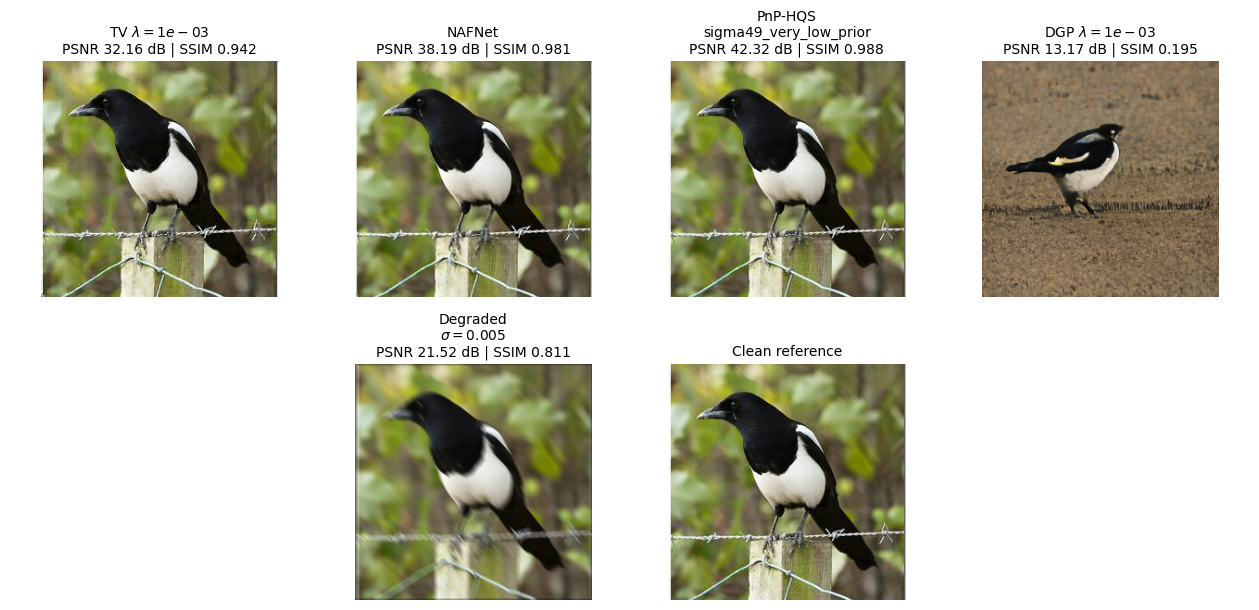

Saved grid to: results/final/comparison/noise_005/comparison_image_1_full.png


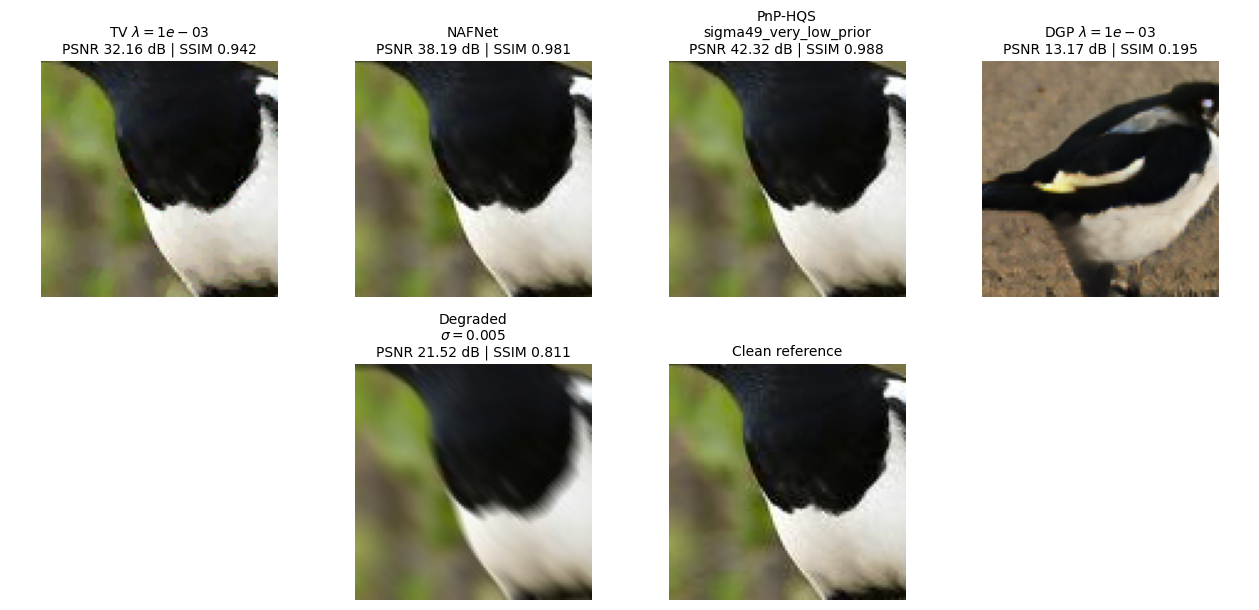

Saved grid to: results/final/comparison/noise_005/comparison_image_1_crop.png
Running TV reconstruction with lambda = 1.0e-04
Done | PSNR=26.34 dB | SSIM=0.6490 | RE=0.1015
Running TV reconstruction with lambda = 3.0e-04
Done | PSNR=29.01 dB | SSIM=0.8046 | RE=0.0746
Running TV reconstruction with lambda = 1.0e-03
Done | PSNR=30.88 dB | SSIM=0.9069 | RE=0.0602
Running TV reconstruction with lambda = 3.0e-03
Done | PSNR=31.09 dB | SSIM=0.9270 | RE=0.0587
Running TV reconstruction with lambda = 1.0e-02
Done | PSNR=30.74 dB | SSIM=0.9256 | RE=0.0611
Running TV reconstruction with lambda = 3.0e-02
Done | PSNR=28.44 dB | SSIM=0.8965 | RE=0.0796
Running TV reconstruction with lambda = 1.0e-01
Done | PSNR=24.80 dB | SSIM=0.8367 | RE=0.1211
Running TV reconstruction with lambda = 3.0e-01
Done | PSNR=22.70 dB | SSIM=0.7567 | RE=0.1542
Running PnP-HQS reconstruction with schedule = sigma49_very_low_prior
Done | PSNR=39.36 dB | SSIM=0.9791 | RE=0.0226
Running PnP-HQS reconstruction with schedule 

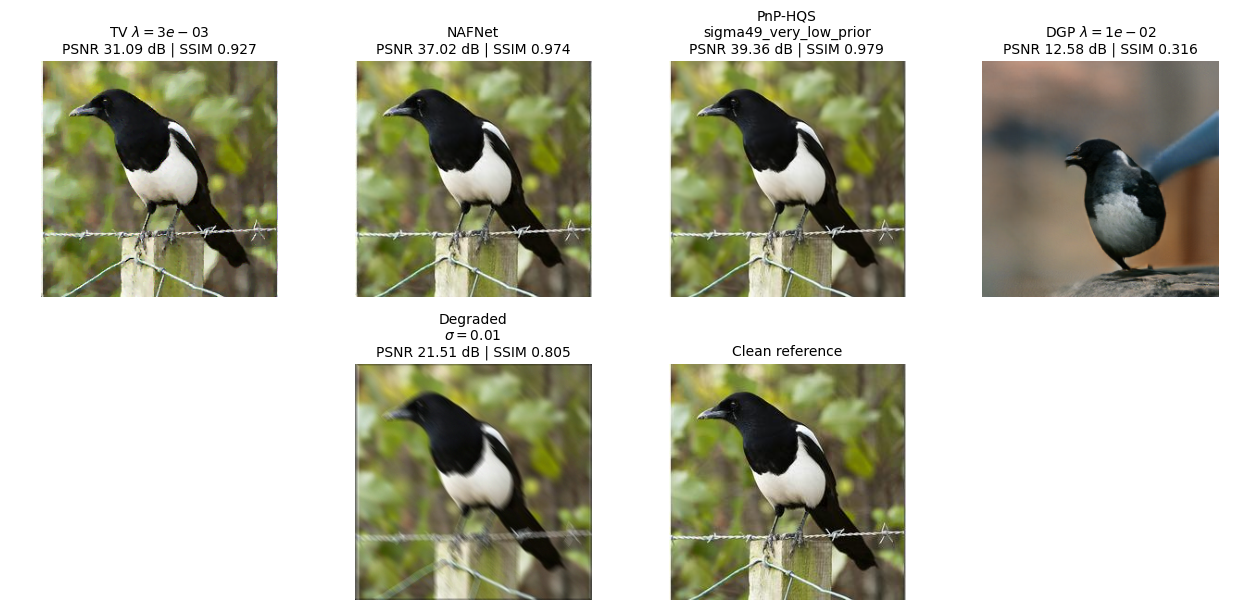

Saved grid to: results/final/comparison/noise_010/comparison_image_1_full.png


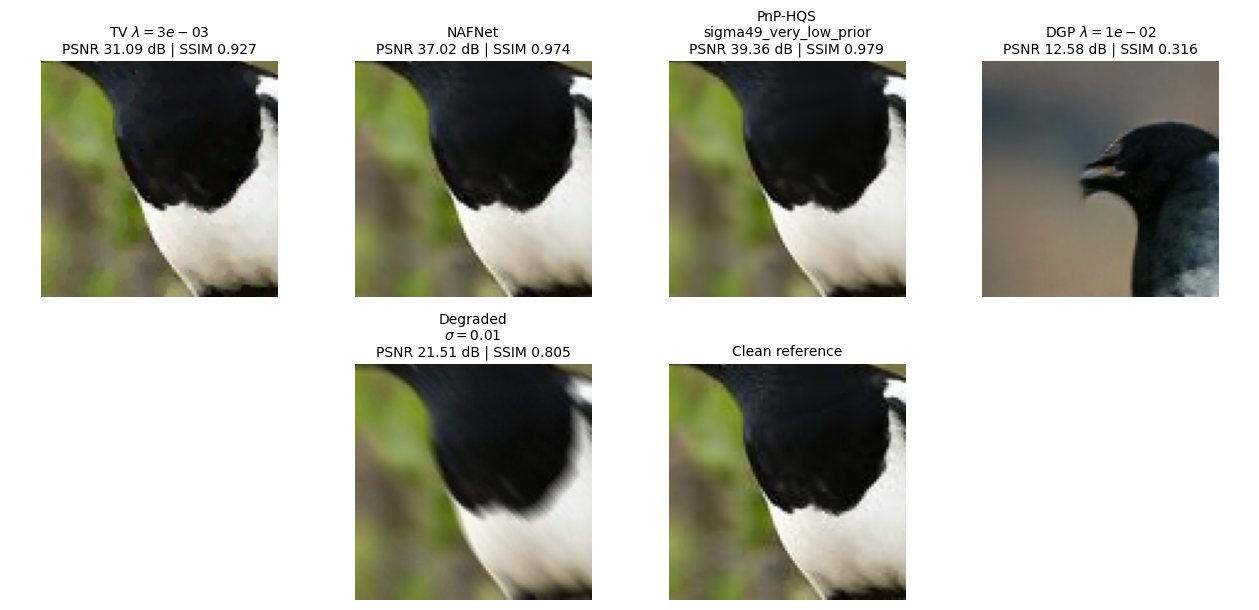

Saved grid to: results/final/comparison/noise_010/comparison_image_1_crop.png
Running TV reconstruction with lambda = 1.0e-04
Done | PSNR=13.64 dB | SSIM=0.1726 | RE=0.4376
Running TV reconstruction with lambda = 3.0e-04
Done | PSNR=13.89 dB | SSIM=0.1782 | RE=0.4251
Running TV reconstruction with lambda = 1.0e-03
Done | PSNR=14.43 dB | SSIM=0.1930 | RE=0.3996
Running TV reconstruction with lambda = 3.0e-03
Done | PSNR=15.93 dB | SSIM=0.2380 | RE=0.3363
Running TV reconstruction with lambda = 1.0e-02
Done | PSNR=22.72 dB | SSIM=0.5158 | RE=0.1539
Running TV reconstruction with lambda = 3.0e-02
Done | PSNR=27.07 dB | SSIM=0.8197 | RE=0.0932
Running TV reconstruction with lambda = 1.0e-01
Done | PSNR=24.73 dB | SSIM=0.8336 | RE=0.1221
Running TV reconstruction with lambda = 3.0e-01
Done | PSNR=22.69 dB | SSIM=0.7564 | RE=0.1544
Running PnP-HQS reconstruction with schedule = sigma49_very_low_prior
Done | PSNR=32.89 dB | SSIM=0.9354 | RE=0.0477
Running PnP-HQS reconstruction with schedule 

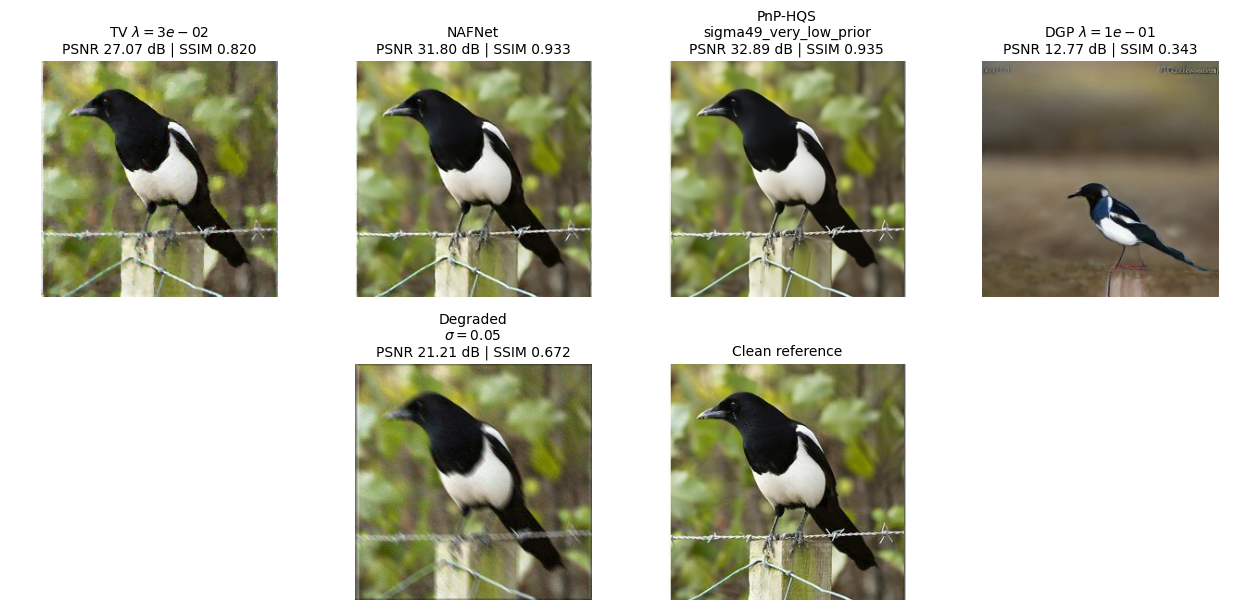

Saved grid to: results/final/comparison/noise_050/comparison_image_1_full.png


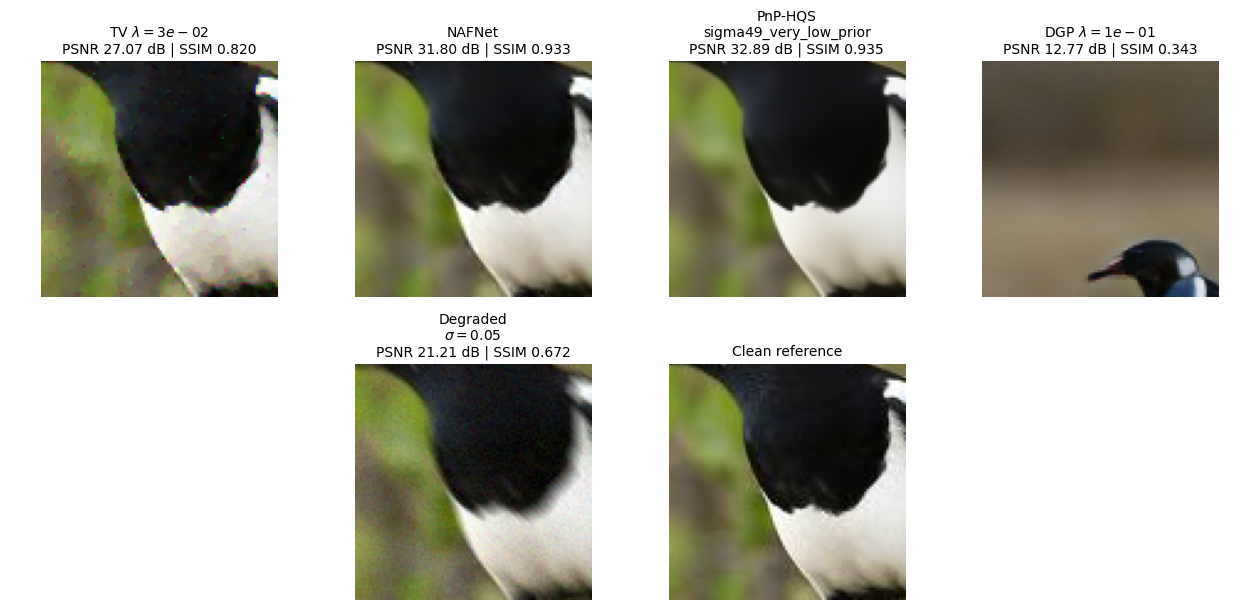

Saved grid to: results/final/comparison/noise_050/comparison_image_1_crop.png
Running TV reconstruction with lambda = 1.0e-04
Done | PSNR=10.33 dB | SSIM=0.1017 | RE=0.6410
Running TV reconstruction with lambda = 3.0e-04
Done | PSNR=10.38 dB | SSIM=0.1024 | RE=0.6373
Running TV reconstruction with lambda = 1.0e-03
Done | PSNR=10.54 dB | SSIM=0.1049 | RE=0.6252
Running TV reconstruction with lambda = 3.0e-03
Done | PSNR=10.93 dB | SSIM=0.1127 | RE=0.5978
Running TV reconstruction with lambda = 1.0e-02
Done | PSNR=12.76 dB | SSIM=0.1519 | RE=0.4846
Running TV reconstruction with lambda = 3.0e-02
Done | PSNR=21.25 dB | SSIM=0.4472 | RE=0.1822
Running TV reconstruction with lambda = 1.0e-01
Done | PSNR=24.43 dB | SSIM=0.8085 | RE=0.1263
Running TV reconstruction with lambda = 3.0e-01
Done | PSNR=22.67 dB | SSIM=0.7543 | RE=0.1548
Running PnP-HQS reconstruction with schedule = sigma49_very_low_prior
Done | PSNR=29.86 dB | SSIM=0.9004 | RE=0.0676
Running PnP-HQS reconstruction with schedule 

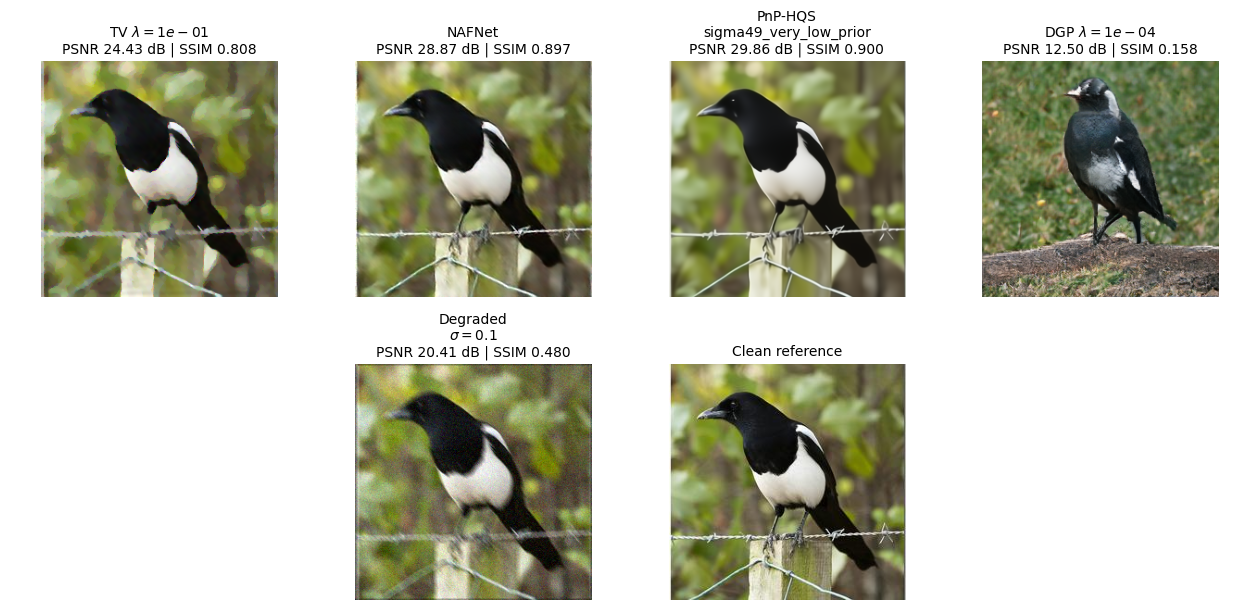

Saved grid to: results/final/comparison/noise_100/comparison_image_1_full.png


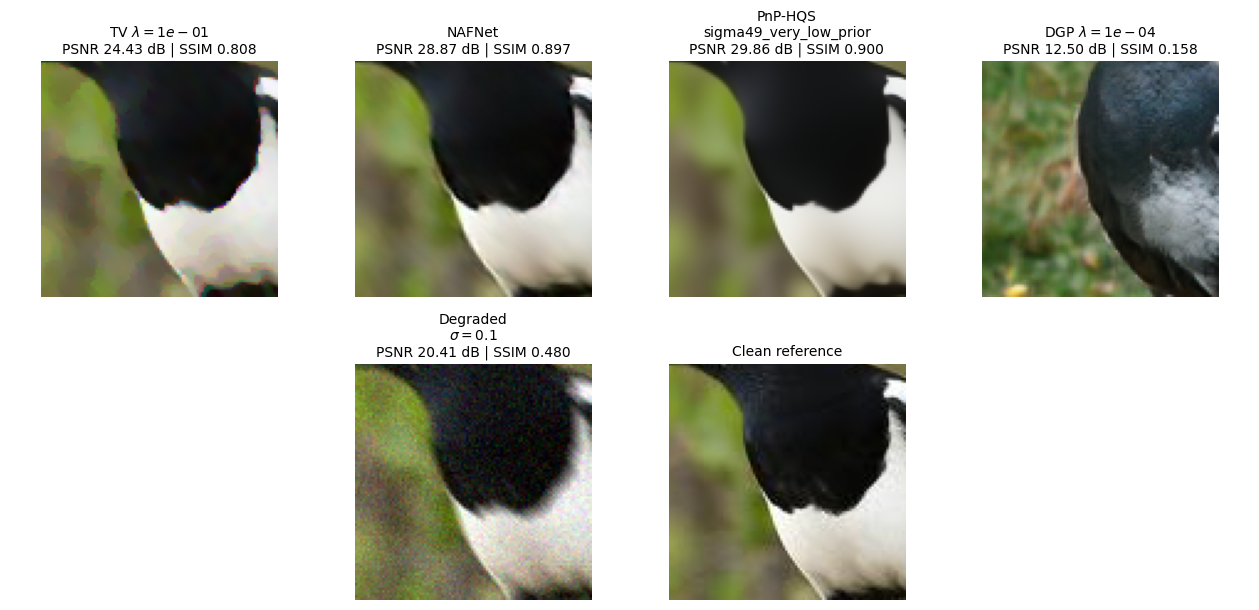

Saved grid to: results/final/comparison/noise_100/comparison_image_1_crop.png


In [3]:
# Comparative qualitative evaluation: all methods, full image + crop
# One figure per noise level:
# top row    -> reconstructions
# bottom row -> degraded + clean, centered

import os
import torch
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


image_index = 1
base_dir = "results/final/comparison"

crop_box = (50, 60, 96, 96)  # x0, y0, width, height


def crop_tensor(img, crop_box):
    x0, y0, w, h = crop_box
    return img[..., y0:y0 + h, x0:x0 + w]


def to_numpy_image(tensor):
    return (
        tensor.detach()
        .cpu()
        .squeeze(0)
        .permute(1, 2, 0)
        .clamp(0.0, 1.0)
    )


def scalar(value):
    return value.item() if isinstance(value, torch.Tensor) else value


def compute_metrics(reconstruction, clean):
    psnr = scalar(PSNR(reconstruction.detach().cpu(), clean.detach().cpu()))
    ssim = scalar(SSIM(reconstruction.detach().cpu(), clean.detach().cpu()))
    return psnr, ssim


@torch.no_grad()
def run_nafnet(nafnet, degraded):
    nafnet.eval()

    reconstruction = nafnet(degraded.to(DEVICE))
    reconstruction = reconstruction.clamp(0.0, 1.0)

    return reconstruction.detach().cpu()


def run_tv(tv, degraded, clean, degradation, save_dir):
    K_tv = degradation.operator.K

    tv_results = tv(
        y_d=degraded,
        K=K_tv,
        x_gt=clean,
        save_dir=save_dir,
        preview=False,
    )

    best_result = max(
        tv_results,
        key=lambda result: scalar(result["psnr"]),
    )

    reconstruction = best_result["reconstruction"].detach().cpu()

    return reconstruction, best_result


def run_pnp_hqs(pnp_hqs, degraded, clean, degradation, save_dir, noise_level):
    K_pnp = degradation.operator

    pnp_results = pnp_hqs(
        y_d=degraded,
        K=K_pnp,
        x_gt=clean,
        noise_level=noise_level,
        save_dir=save_dir,
        preview=False,
    )

    best_result = max(
        pnp_results,
        key=lambda result: scalar(result["psnr"]),
    )

    reconstruction = best_result["reconstruction"].detach().cpu()

    return reconstruction, best_result


def run_dgp(dgp, degraded, clean, degradation, save_dir):
    K_dgp = degradation.operator

    dgp_results = dgp(
        y_d=degraded,
        K=K_dgp,
        x_gt=clean,
        save_dir=save_dir,
        preview=False,
    )

    best_result = max(
        dgp_results,
        key=lambda result: scalar(result["psnr"]),
    )

    reconstruction = best_result["reconstruction"].detach().cpu()

    return reconstruction, best_result


def get_pnp_label(pnp_best):
    if "schedule_name" in pnp_best:
        return f"PnP-HQS\n{pnp_best['schedule_name']}"

    if "schedule" in pnp_best:
        return f"PnP-HQS\n{pnp_best['schedule']}"

    return "PnP-HQS"


def plot_comparison_grid(
    clean,
    degraded,
    reconstructions,
    noise_level,
    save_path,
    crop_box=None,
):
    if crop_box is not None:
        clean_show = crop_tensor(clean, crop_box)
        degraded_show = crop_tensor(degraded, crop_box)

        reconstructions_show = {
            name: crop_tensor(img, crop_box)
            for name, img in reconstructions.items()
        }
    else:
        clean_show = clean
        degraded_show = degraded
        reconstructions_show = reconstructions

    method_names = list(reconstructions_show.keys())
    n_methods = len(method_names)

    fig = plt.figure(figsize=(4 * n_methods, 7))

    gs = GridSpec(
        2,
        n_methods,
        figure=fig,
        height_ratios=[1, 1],
        hspace=0.28,
        wspace=0.05,
    )

    # Row 1: reconstructions
    for col, method_name in enumerate(method_names):
        reconstruction_show = reconstructions_show[method_name]
        reconstruction_full = reconstructions[method_name]

        psnr_r, ssim_r = compute_metrics(reconstruction_full, clean)

        ax = fig.add_subplot(gs[0, col])
        ax.imshow(to_numpy_image(reconstruction_show))
        ax.axis("off")

        ax.set_title(
            f"{method_name}\n"
            f"PSNR {psnr_r:.2f} dB | SSIM {ssim_r:.3f}",
            fontsize=10,
            pad=6,
        )

    # Row 2: degraded + clean centered
    center_start = (n_methods - 2) // 2
    used_cols = {center_start, center_start + 1}

    degraded_ax = fig.add_subplot(gs[1, center_start])
    degraded_ax.imshow(to_numpy_image(degraded_show))
    degraded_ax.axis("off")

    psnr_d, ssim_d = compute_metrics(degraded, clean)

    degraded_ax.set_title(
        f"Degraded\n"
        f"$\\sigma={noise_level}$\n"
        f"PSNR {psnr_d:.2f} dB | SSIM {ssim_d:.3f}",
        fontsize=10,
        pad=6,
    )

    clean_ax = fig.add_subplot(gs[1, center_start + 1])
    clean_ax.imshow(to_numpy_image(clean_show))
    clean_ax.axis("off")
    clean_ax.set_title("Clean reference", fontsize=10, pad=6)

    for col in range(n_methods):
        if col not in used_cols:
            ax = fig.add_subplot(gs[1, col])
            ax.axis("off")

    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    print(f"Saved grid to: {save_path}")


# Freeze NAFNet explicitly
nafnet.eval()

for parameter in nafnet.parameters():
    parameter.requires_grad = False


clean = test_dataset[image_index].unsqueeze(0).to(DEVICE)


for noise_level in NOISE_LEVELS:
    noise_name = f"noise_{int(noise_level * 1000):03d}"

    degradation = ImageDegradation(
        DegradationParameters(
            image_size=IMAGE_SIZE,
            kernel_type="motion",
            kernel_size=9,
            motion_angle=45,
            noise_levels=[noise_level],
        )
    )

    # Important:
    # same pipeline as the standalone NAFNet evaluation
    degraded = degradation(clean).to(DEVICE)

    clean_cpu = clean.detach().cpu()
    degraded_cpu = degraded.detach().cpu()

    reconstructions = {}

    # TV
    tv_rec, tv_best = run_tv(
        tv=tv,
        degraded=degraded_cpu,
        clean=clean_cpu,
        degradation=degradation,
        save_dir=f"{base_dir}/{noise_name}/image_{image_index}/TV",
    )

    reconstructions[f"TV $\\lambda={tv_best['lambda']:.0e}$"] = tv_rec

    # NAFNet
    nafnet_rec = run_nafnet(
        nafnet=nafnet,
        degraded=degraded,
    )

    reconstructions["NAFNet"] = nafnet_rec

    # PnP-HQS
    pnp_rec, pnp_best = run_pnp_hqs(
        pnp_hqs=pnp_hqs,
        degraded=degraded_cpu,
        clean=clean_cpu,
        degradation=degradation,
        save_dir=f"{base_dir}/{noise_name}/image_{image_index}/PnP-HQS",
        noise_level=noise_level,
    )

    reconstructions[get_pnp_label(pnp_best)] = pnp_rec

    # DGP
    dgp_rec, dgp_best = run_dgp(
        dgp=dgp,
        degraded=degraded_cpu,
        clean=clean_cpu,
        degradation=degradation,
        save_dir=f"{base_dir}/{noise_name}/image_{image_index}/DGP",
    )

    reconstructions[f"DGP $\\lambda={dgp_best['lambda']:.0e}$"] = dgp_rec

    # Full image
    plot_comparison_grid(
        clean=clean_cpu,
        degraded=degraded_cpu,
        reconstructions=reconstructions,
        noise_level=noise_level,
        save_path=f"{base_dir}/{noise_name}/comparison_image_{image_index}_full.png",
        crop_box=None,
    )

    # Crop
    plot_comparison_grid(
        clean=clean_cpu,
        degraded=degraded_cpu,
        reconstructions=reconstructions,
        noise_level=noise_level,
        save_path=f"{base_dir}/{noise_name}/comparison_image_{image_index}_crop.png",
        crop_box=crop_box,
    )